In [18]:
# Import packages
import numpy as np
import pandas as pd
import hdbscan
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn import datasets, linear_model, metrics
from sklearn.linear_model import LinearRegression
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from functions_fcsuml import *



# Recursive clustering

In [19]:

def clustering(data, cluster_size=10, min_samples=10, distance_type='euclidean'):
    """Takes data, minimum cluster size, distance metric and returns an array of the data with an added column at index 0 with the cluster label and the number of clusters."""
    clusterer = hdbscan.HDBSCAN(min_cluster_size=cluster_size, min_samples=min_samples ,  metric=distance_type)    # , approx_min_span_tree=True, algorithm='boruvka_balltree'
    # print('shape:', data.shape[0], 'dim:', data.ndim)
    clusterer.fit(data)
    return clusterer.labels_.max()+1 , np.insert(data, 0, clusterer.labels_.flatten(), axis=1)

def create_clusterspan(sorted_clusters, number_of_clusters):
    clusterspan = np.zeros(number_of_clusters+2)

    for i in range(0, number_of_clusters+1):
        clusterspan[i+1] = clusterspan[i] + np.shape(sorted_clusters[np.where(sorted_clusters[:,0] == i)])[0]

    clusterspan[-1] = np.shape(sorted_clusters)[0]
    return clusterspan


def silhouette(SC, NC):
    labels = SC[:, 0]
    silhouettes = metrics.silhouette_samples(SC[:, 1:], labels)
    cluster_silhouettes = np.zeros((NC, 2))
    
    for i in range(1, NC+1):
        # print(i, NC)
        cluster_silhouettes[i-1,:] = i, np.mean(silhouettes[np.where(SC[:, 0] == i)])

    return np.mean(silhouettes), cluster_silhouettes



def optimal_cluster_size(data, max_MCS = 9000, min_MCS = 1000, step_size = 1000, max_recursion = 1000, recursion = 0, first_calc=0):
    print(f'Recursion: {recursion}, data shape: {np.shape(data)}, min_MCS: {min_MCS}')
    backup = min_MCS 
    
    if first_calc !=0:
        min_MCS = first_calc
    
    max_iterations = (max_MCS-min_MCS) // step_size + 1
    Sil_mat = np.zeros((max_iterations, 3))

    cluster_mat = np.zeros((np.shape(data)[0], np.shape(data)[1]+1, max_iterations)) # For saving results

    best_silhouette = -1
    best_index = 0
    best_cluster_index = 0

    for MCS in range(min_MCS, max_MCS+1, step_size): # range(2, data_points): # MCS = minimum cluster size  range(9, 11): # 
        index = (MCS-min_MCS)//step_size
        # print('shape:', data.shape, 'dim:', data.ndim)

        number_of_clusters, clustered_data = clustering(data, cluster_size=MCS, min_samples=2)
        

        if number_of_clusters < 2:
            Sil_mat[index] = MCS, 0, number_of_clusters
            print(f'{MCS} skipped because number of clusters < 2.')
            break

        clustered_data[:, 0] += 1
        

        sorted_clusters = clustered_data[clustered_data[:, 0].argsort()] # sorting the clustered data by cluster affiliation

        cluster_mat[:,:, index] = sorted_clusters

        clusterspan = create_clusterspan(sorted_clusters, number_of_clusters)
        print(clusterspan)


        average_silhouette, cluster_silhouettes = silhouette(sorted_clusters, number_of_clusters)
        print('avg:', average_silhouette, 'clu: \n', cluster_silhouettes)

        if average_silhouette > best_silhouette:
            best_silhouette, best_index, best_cluster_index = average_silhouette, index, np.argmax(cluster_silhouettes[:, 1])

        Sil_mat[index] = MCS, average_silhouette, number_of_clusters

    print(best_silhouette, best_index, best_cluster_index)

    if best_silhouette == -1:
        print(f'Stop. Cannot cluster further.')
        print('data: ', np.shape(data))
        return np.insert(data, 0, 1, axis=1)

    # print(Sil_mat)
    min_MCS = backup
    # b = a[np.where(a[1] < 3)]

    cluster_mat_best = cluster_mat[:, :, best_index]
 
    best_cluster = cluster_mat_best[np.where(cluster_mat_best[:, 0] == (best_cluster_index+1))]
    remaining_clusters = cluster_mat_best[np.where(cluster_mat_best[:, 0] != (best_cluster_index+1))]

    # print(remaining_clusters.shape)
    # print(np.where(remaining_clusters == 1))

    if best_cluster_index != 0:
        remaining_clusters[np.where(remaining_clusters[:, 0] == 1), 0] = best_cluster_index+1
        best_cluster[:, 0] = 1
    
    # print('bclu 1st: ', best_cluster[0,0])
    # print('remclu: ',remaining_clusters[:, 0])

    size_bc = np.shape(best_cluster)[0]
    size_rc = np.shape(remaining_clusters)[0]

    if recursion < max_recursion and size_bc > 0 and size_rc > 0:
        print(f'size_bc: {size_bc}, size_rc: {size_rc}')
        if  size_bc > min_MCS and size_bc > 3:
            # print(f'new max: {np.min([max_MCS, size_bc-2])}')
            
            new_min_bc = np.max((int(size_bc/2), 2))
            partition_1 = optimal_cluster_size(best_cluster[:, 1:], np.min([max_MCS, size_bc-2]), np.min([min_MCS, new_min_bc]), step_size=step_size, max_recursion=max_recursion, recursion=recursion+1)
        else:
            partition_1 = best_cluster
            # partition_1[:, 0] = 1

        if  size_rc > min_MCS and size_rc > 3:
            # print(f'new max: {np.min([max_MCS, size_rc-2])}')
            new_min_rc = np.max((int(size_rc/2), 2))
            partition_2 = optimal_cluster_size(remaining_clusters[:, 1:], np.min([max_MCS, size_rc-2]), np.min([min_MCS, new_min_rc]), step_size=step_size, max_recursion=max_recursion, recursion=recursion+1)
        else:
            partition_2 = remaining_clusters

        if np.min(partition_1[:,0] == 0): # All points in partition_1 should belong to a cluster
            print(f'min partition_1 = 0') # , patition_1: {partition_1}
            partition_1[:, 0] += 1
    else:
        partition_1 = best_cluster
        partition_2 = remaining_clusters



        # partition_3 = partition_2[np.where(partition_2[:, 0] == 0)]
        # partition_2 = partition_2[np.where(partition_2[:, 0] != 0)]
        # partition_2[np.where(partition_2[:, 0] < best_cluster_index+1), 0] += 1
        # partition_2 = np.vstack((partition_2, partition_3))
        # partition_1[:, 0] = 1


    # print('par2', partition_2[:, 0])

    partition_3 = partition_2[np.where(partition_2[:, 0] == 0)]
    partition_2 = partition_2[np.where(partition_2[:, 0] != 0)]

    if np.min(partition_2[:, 0]) <= np.max(partition_1[:, 0]):     # np.shape(partition_1)[0] > 0:
        partition_2[:, 0] += 1 # np.max(partition_1[:,0])-np.min(partition_2[:, 0])

    print(f'p1: {np.shape(partition_1)}, p2: {np.shape(partition_2)}, p3: {np.shape(partition_3)}')
    print(f'stack shape: {np.vstack((partition_1, partition_2, partition_3)).shape}')

    return np.vstack((partition_1, partition_2, partition_3))


## Preparing data

In [20]:
blobs_100, labels_100, centers_100 = datasets.make_blobs(n_samples=70000, n_features=50, centers=100, random_state=42, return_centers=True)

blobs_50, labels_50, centers_50 = datasets.make_blobs(n_samples=70000, n_features=50, centers=50, random_state=42, return_centers=True)

blobs_20, labels_20, centers_20 = datasets.make_blobs(n_samples=70000, n_features=50, centers=20, random_state=42, return_centers=True)


print(blobs_100.shape, blobs_20.shape)

(70000, 50) (70000, 50)


In [21]:
norm_100, normalization_variables_100 = normalize(blobs_100)
norm_50, normalization_variables_50 = normalize(blobs_50)
norm_20, normalization_variables_20 = normalize(blobs_20)

print(norm_20.shape, norm_100.shape)

(70000, 50) (70000, 50)


## 100 clusters

In [22]:
optimal_clustering = optimal_cluster_size(blobs_100, 2100, 100, 1000)
print(optimal_clustering)


Recursion: 0, data shape: (70000, 50), min_MCS: 100
[    0.     0.   700.  1400.  2100.  2800.  3500.  4200.  4900.  5600.
  6300.  7000.  7700.  8400.  9100.  9800. 10500. 11200. 11900. 12600.
 13300. 14000. 14700. 15400. 16100. 16800. 17500. 18200. 18900. 19600.
 20300. 21000. 21700. 22400. 23100. 23800. 24500. 25200. 25900. 26600.
 27300. 28000. 28700. 29400. 30100. 30800. 31500. 32200. 32900. 33600.
 34300. 35000. 35700. 36400. 37100. 37800. 38500. 39200. 39900. 40600.
 41300. 42000. 42700. 43400. 44100. 44800. 45500. 46200. 46900. 47600.
 48300. 49000. 49700. 50400. 51100. 51800. 52500. 53200. 53900. 54600.
 55300. 56000. 56700. 57400. 58100. 58800. 59500. 60200. 60900. 61600.
 62300. 63000. 63700. 64400. 65100. 65800. 66500. 67200. 67900. 68600.
 69300. 70000.]
avg: 0.7863420685955027 clu: 
 [[  1.           0.80060646]
 [  2.           0.81010257]
 [  3.           0.80247204]
 [  4.           0.8057449 ]
 [  5.           0.80539385]
 [  6.           0.79847924]
 [  7.           

[    0.     0.   700.  1400.  2100.  2800.  3500.  4200.  4900.  5600.
  6300.  7000.  7700.  8400.  9100.  9800. 10500. 11200. 11900. 12600.
 13300. 14000. 14700. 15400. 16100. 16800. 17500. 18200. 18900. 19600.
 20300. 21000. 21700. 22400. 23100. 23800. 24500. 25200. 25900. 26600.
 27300. 28000. 28700. 29400. 30100. 30800. 31500. 32200. 32900. 33600.
 34300. 35000. 35700. 36400. 37100. 37800. 38500. 39200. 39900. 40600.
 41300. 42000. 42700. 43400. 44100. 44800. 45500. 46200. 46900. 47600.
 48300. 49000. 49700. 50400. 51100. 51800. 52500. 53200. 53900. 54600.
 55300. 56000. 56700. 57400. 58100. 58800. 59500. 60200. 60900. 61600.
 62300. 63000. 63700. 64400. 65100. 65800. 66500. 67200. 67900. 68600.
 69300. 70000.]
avg sil: 0.7863420685955027 
 cluster silhouettes: 
 [[  1.           0.81010257]
 [  2.           0.8057449 ]
 [  3.           0.80539385]
 [  4.           0.80291245]
 [  5.           0.80247204]
 [  6.           0.80242817]
 [  7.           0.80186801]
 [  8.           0

c:\Users\Projektlotsarna\Code\Exjobb\Finding-comparable-sales-using-macine-learning\functions_fcsuml.py:101: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x1, y1, c = cmap(i), s = 1)


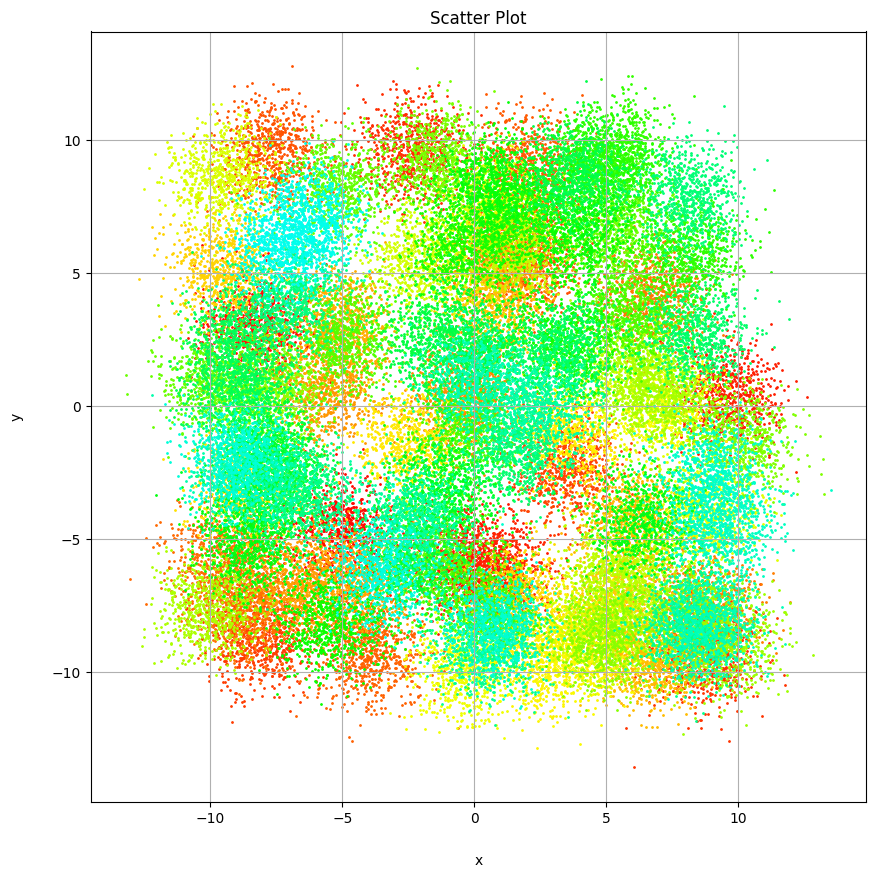

In [23]:
sorted_clusters = optimal_clustering[optimal_clustering[:, 0].argsort()] # sorting the clustered data by cluster affiliation
number_of_clusters = int(np.max(sorted_clusters[:,0]))
clusterspan = create_clusterspan(sorted_clusters, number_of_clusters)
print(clusterspan)
average_silhouette, cluster_silhouettes = silhouette(sorted_clusters, number_of_clusters)
print('avg sil:', average_silhouette, '\n cluster silhouettes: \n', cluster_silhouettes, '\n argmax', np.argmax(cluster_silhouettes[:,1]))
show_clusters_in_latlon(blobs_100, sorted_clusters, number_of_clusters, clusterspan,2, 1)

## 50 clusters

In [24]:
optimal_clustering_50 = optimal_cluster_size(blobs_50, 2100, 100, 1000)
print(optimal_clustering_50)


Recursion: 0, data shape: (70000, 50), min_MCS: 100
[    0.     0.  1400.  2800.  4200.  5600.  7000.  8400.  9800. 11200.
 12600. 14000. 15400. 16800. 18200. 19600. 21000. 22400. 23800. 25200.
 26600. 28000. 29400. 30800. 32200. 33600. 35000. 36400. 37800. 39200.
 40600. 42000. 43400. 44800. 46200. 47600. 49000. 50400. 51800. 53200.
 54600. 56000. 57400. 58800. 60200. 61600. 63000. 64400. 65800. 67200.
 68600. 70000.]
avg: 0.7933511594296264 clu: 
 [[ 1.          0.79780917]
 [ 2.          0.80615202]
 [ 3.          0.79604863]
 [ 4.          0.79861988]
 [ 5.          0.79724458]
 [ 6.          0.81498965]
 [ 7.          0.81200983]
 [ 8.          0.80996707]
 [ 9.          0.79835633]
 [10.          0.80796804]
 [11.          0.80804571]
 [12.          0.80814096]
 [13.          0.80987505]
 [14.          0.80080576]
 [15.          0.79973775]
 [16.          0.80471996]
 [17.          0.80242003]
 [18.          0.79651722]
 [19.          0.79410092]
 [20.          0.80570679]
 [21. 

[    0.     0.  1400.  2800.  4200.  5600.  7000.  8400.  9800. 11200.
 12600. 14000. 15400. 16800. 18200. 19600. 21000. 22400. 23800. 25200.
 26600. 28000. 29400. 30800. 32200. 33600. 35000. 36400. 37800. 39200.
 40600. 42000. 43400. 44800. 46200. 47600. 49000. 50400. 51800. 53200.
 54600. 56000. 57400. 58800. 60200. 61600. 63000. 64400. 65800. 67200.
 68600. 70000.]
avg sil: 0.7933511594296264 
 cluster silhouettes: 
 [[ 1.          0.81498965]
 [ 2.          0.81200983]
 [ 3.          0.80996707]
 [ 4.          0.80987505]
 [ 5.          0.80814096]
 [ 6.          0.80804571]
 [ 7.          0.80796804]
 [ 8.          0.80615202]
 [ 9.          0.80570679]
 [10.          0.80471996]
 [11.          0.8042765 ]
 [12.          0.80242003]
 [13.          0.80177287]
 [14.          0.80174061]
 [15.          0.80080576]
 [16.          0.79973775]
 [17.          0.79879263]
 [18.          0.79861988]
 [19.          0.79724458]
 [20.          0.79835633]
 [21.          0.79684169]
 [22.    

c:\Users\Projektlotsarna\Code\Exjobb\Finding-comparable-sales-using-macine-learning\functions_fcsuml.py:101: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x1, y1, c = cmap(i), s = 1)


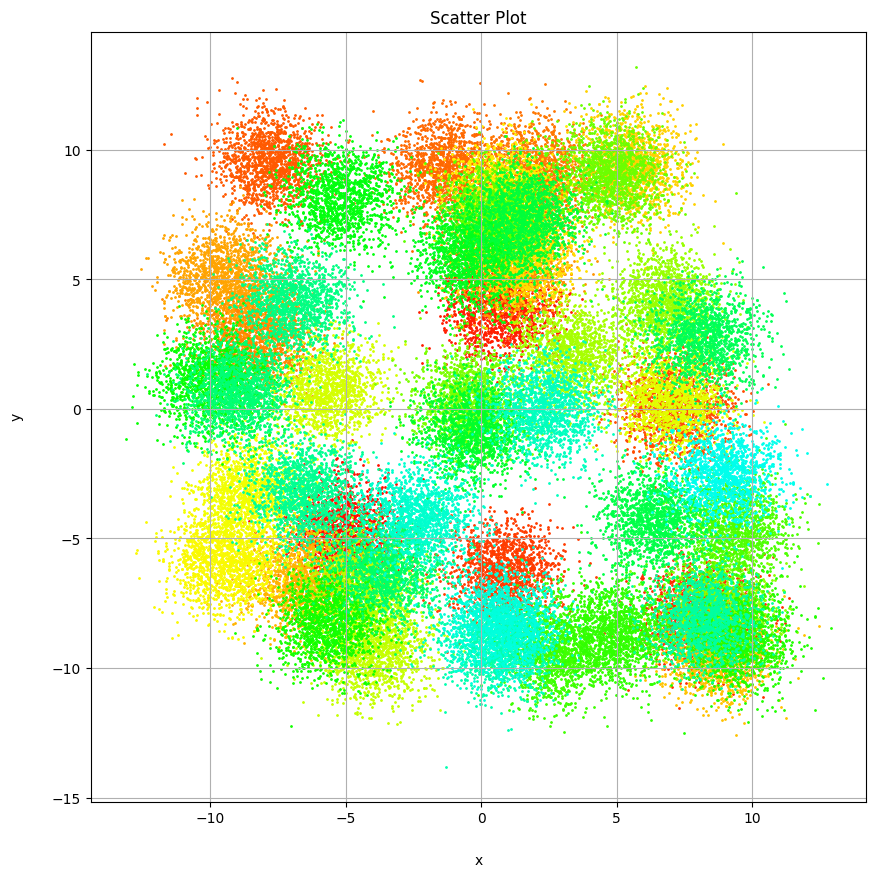

In [25]:
sorted_clusters = optimal_clustering_50[optimal_clustering_50[:, 0].argsort()] # sorting the clustered data by cluster affiliation
number_of_clusters = int(np.max(sorted_clusters[:,0]))
clusterspan = create_clusterspan(sorted_clusters, number_of_clusters)
print(clusterspan)
average_silhouette, cluster_silhouettes = silhouette(sorted_clusters, number_of_clusters)
print('avg sil:', average_silhouette, '\n cluster silhouettes: \n', cluster_silhouettes, '\n argmax', np.argmax(cluster_silhouettes[:,1]))
show_clusters_in_latlon(blobs_50, sorted_clusters, number_of_clusters, clusterspan,2, 1)

## 20 clusters

In [26]:
optimal_clustering_20 = optimal_cluster_size(blobs_20, 2100, 100, 1000)
print(optimal_clustering_20)


Recursion: 0, data shape: (70000, 50), min_MCS: 100
[    0.     0.  3500.  7000. 10500. 14000. 17500. 21000. 24500. 28000.
 31500. 35000. 38500. 42000. 45500. 49000. 52500. 56000. 59500. 63000.
 66500. 70000.]
avg: 0.8016668187958406 clu: 
 [[ 1.          0.80533721]
 [ 2.          0.82656064]
 [ 3.          0.81905781]
 [ 4.          0.80583085]
 [ 5.          0.81095234]
 [ 6.          0.80583066]
 [ 7.          0.80631356]
 [ 8.          0.81043286]
 [ 9.          0.80640015]
 [10.          0.81058455]
 [11.          0.79370018]
 [12.          0.79340759]
 [13.          0.8013886 ]
 [14.          0.80471805]
 [15.          0.80026613]
 [16.          0.80889976]
 [17.          0.76210566]
 [18.          0.76236376]
 [19.          0.7996396 ]
 [20.          0.79954641]]
[    0.     0.  3500.  7000. 10500. 14000. 17500. 21000. 24500. 28000.
 31500. 35000. 38500. 42000. 45500. 49000. 52500. 56000. 59500. 63000.
 66500. 70000.]
avg: 0.8016668187958406 clu: 
 [[ 1.          0.80533721]
 [

[    0.     0.  3500.  7000. 10500. 14000. 17500. 21000. 24500. 28000.
 31500. 35000. 38500. 42000. 45500. 49000. 52500. 56000. 59500. 63000.
 66500. 70000.]
avg sil: 0.8016668187958407 
 cluster silhouettes: 
 [[ 1.          0.82656064]
 [ 2.          0.81905781]
 [ 3.          0.81095234]
 [ 4.          0.81058455]
 [ 5.          0.81043286]
 [ 6.          0.80889976]
 [ 7.          0.80640015]
 [ 8.          0.80631356]
 [ 9.          0.80583066]
 [10.          0.80583085]
 [11.          0.80533721]
 [12.          0.80471805]
 [13.          0.8013886 ]
 [14.          0.80026613]
 [15.          0.7996396 ]
 [16.          0.79954641]
 [17.          0.79370018]
 [18.          0.79340759]
 [19.          0.76236376]
 [20.          0.76210566]] 
 argmax 0


c:\Users\Projektlotsarna\Code\Exjobb\Finding-comparable-sales-using-macine-learning\functions_fcsuml.py:101: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(x1, y1, c = cmap(i), s = 1)


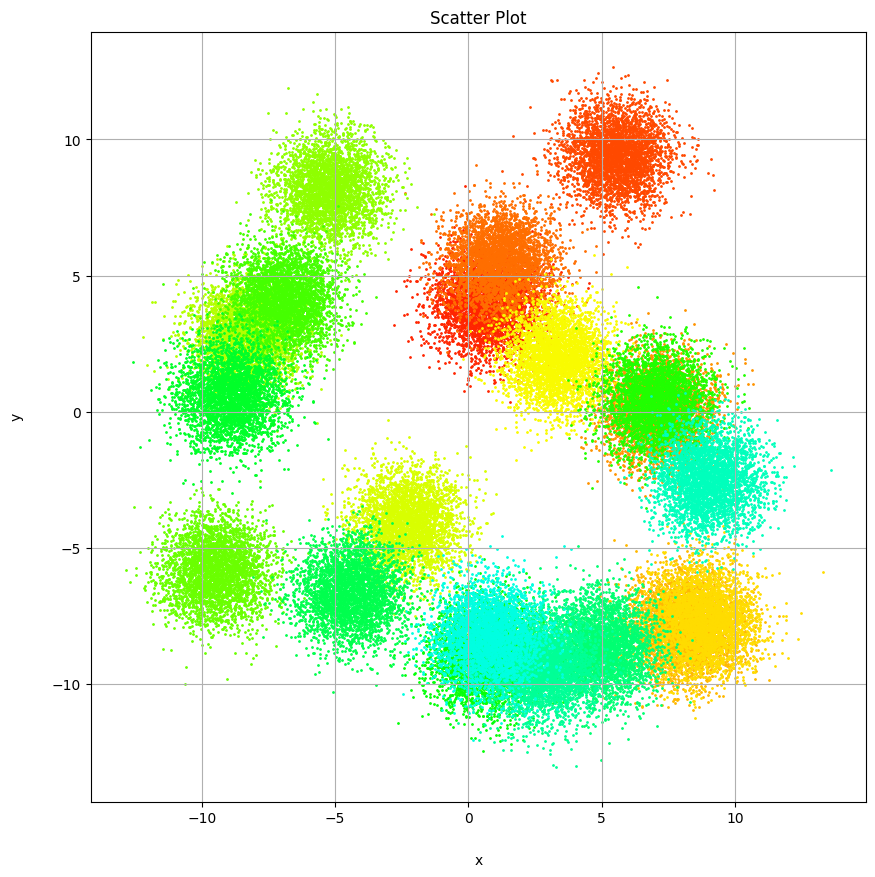

In [27]:
sorted_clusters = optimal_clustering_20[optimal_clustering_20[:, 0].argsort()] # sorting the clustered data by cluster affiliation
number_of_clusters = int(np.max(sorted_clusters[:,0]))
clusterspan = create_clusterspan(sorted_clusters, number_of_clusters)
print(clusterspan)
average_silhouette, cluster_silhouettes = silhouette(sorted_clusters, number_of_clusters)
print('avg sil:', average_silhouette, '\n cluster silhouettes: \n', cluster_silhouettes, '\n argmax', np.argmax(cluster_silhouettes[:,1]))
show_clusters_in_latlon(blobs_20, sorted_clusters, number_of_clusters, clusterspan,2, 1)

# Normal clustering

In [32]:
# 20
NoC_20, clustering_20 = clustering(blobs_20, cluster_size=100, min_samples=2)
sorted_clusters_20 = clustering_20[clustering_20[:, 0].argsort()] # sorting the clustered data by cluster affiliation
sorted_clusters_20[:, 0] +=1
clusterspan_20 = create_clusterspan(sorted_clusters_20, NoC_20)
average_silhouette_20, cluster_silhouettes_20 = silhouette(sorted_clusters_20, NoC_20)
print(NoC_20, clusterspan_20, 'avg sil:', average_silhouette_20)

# 50
NoC_50, clustering_50 = clustering(blobs_50, cluster_size=100, min_samples=2)
sorted_clusters_50 = clustering_50[clustering_50[:, 0].argsort()] # sorting the clustered data by cluster affiliation
sorted_clusters_50[:, 0] +=1
clusterspan_50 = create_clusterspan(sorted_clusters_50, NoC_50)
average_silhouette_50, cluster_silhouettes_50 = silhouette(sorted_clusters_50, NoC_50)
print(NoC_50, clusterspan_50, 'avg sil:', average_silhouette_50)

# 100
NoC_100, clustering_100 = clustering(blobs_100, cluster_size=100, min_samples=2)
sorted_clusters_100 = clustering_100[clustering_100[:, 0].argsort()] # sorting the clustered data by cluster affiliation
sorted_clusters_100[:, 0] +=1
clusterspan_100 = create_clusterspan(sorted_clusters_100, NoC_100)
average_silhouette_100, cluster_silhouettes_100 = silhouette(sorted_clusters_100, NoC_100)
print(NoC_100, clusterspan_100, 'avg sil:', average_silhouette_100)

20 [    0.     0.  3500.  7000. 10500. 14000. 17500. 21000. 24500. 28000.
 31500. 35000. 38500. 42000. 45500. 49000. 52500. 56000. 59500. 63000.
 66500. 70000.] avg sil: 0.8016668187958406
50 [    0.     0.  1400.  2800.  4200.  5600.  7000.  8400.  9800. 11200.
 12600. 14000. 15400. 16800. 18200. 19600. 21000. 22400. 23800. 25200.
 26600. 28000. 29400. 30800. 32200. 33600. 35000. 36400. 37800. 39200.
 40600. 42000. 43400. 44800. 46200. 47600. 49000. 50400. 51800. 53200.
 54600. 56000. 57400. 58800. 60200. 61600. 63000. 64400. 65800. 67200.
 68600. 70000.] avg sil: 0.7933511594296264
100 [    0.     0.   700.  1400.  2100.  2800.  3500.  4200.  4900.  5600.
  6300.  7000.  7700.  8400.  9100.  9800. 10500. 11200. 11900. 12600.
 13300. 14000. 14700. 15400. 16100. 16800. 17500. 18200. 18900. 19600.
 20300. 21000. 21700. 22400. 23100. 23800. 24500. 25200. 25900. 26600.
 27300. 28000. 28700. 29400. 30100. 30800. 31500. 32200. 32900. 33600.
 34300. 35000. 35700. 36400. 37100. 37800. 38500. 